In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch: 2.11.0
CUDA available: True
Using device: cuda
GPU: Tesla T4


# Representation Evaluation

This notebook evaluates the representations learned by the masked particle transformer.

The evaluation includes:

- masked PDG token reconstruction
- continuous particle feature reconstruction
- event-level embedding extraction
- PCA visualization of the learned representation
- analysis of the relationship between the latent space and particle multiplicity

The goal is not to optimize a downstream physics classifier, but to investigate what
information is captured by the self-supervised representation.

# Load the processed dataset

In [2]:
DATA_FILE = "processed_collider_events.pt"

data = torch.load(
    DATA_FILE,
    weights_only=False
)

continuous_list = data["continuous_list"]
pdg_id_list = data["pdg_id_list"]

train_idx = data["train_idx"]
val_idx = data["val_idx"]
test_idx = data["test_idx"]

feature_mean = data["feature_mean"]
feature_std = data["feature_std"]

pdg_to_id = data["pdg_to_id"]

PAD_ID = data["PAD_ID"]
VOCAB_SIZE = data["VOCAB_SIZE"]

print("Dataset loaded.")
print("Events:", len(continuous_list))
print("Train:", len(train_idx))
print("Validation:", len(val_idx))
print("Test:", len(test_idx))
print("Vocabulary size:", VOCAB_SIZE)
print("PDG → token:", pdg_to_id)

Dataset loaded.
Events: 45830
Train: 36664
Validation: 4583
Test: 4583
Vocabulary size: 32
PDG → token: {-3322: 1, -3312: 2, -3222: 3, -3122: 4, -3112: 5, -2212: 6, -2112: 7, -321: 8, -211: 9, -16: 10, -14: 11, -13: 12, -12: 13, -11: 14, 11: 15, 12: 16, 13: 17, 14: 18, 16: 19, 22: 20, 130: 21, 211: 22, 310: 23, 321: 24, 2112: 25, 2212: 26, 3112: 27, 3122: 28, 3222: 29, 3312: 30, 3322: 31}


# Recreate the Dataset

In [3]:
class ColliderEventDataset(torch.utils.data.Dataset):

    def __init__(
        self,
        event_indices,
        feature_lists,
        pdg_lists,
        mean,
        std
    ):

        self.event_indices = np.asarray(event_indices)
        self.feature_lists = feature_lists
        self.pdg_lists = pdg_lists

        self.mean = np.asarray(mean, dtype=np.float32)
        self.std = np.asarray(std, dtype=np.float32)

    def __len__(self):
        return len(self.event_indices)

    def __getitem__(self, idx):

        event_index = int(self.event_indices[idx])

        rows = []

        for p in self.feature_lists[event_index]:

            rows.append([
                p["log_pt"],
                p["eta"],
                p["sin_phi"],
                p["cos_phi"],
                p["log_energy"],
                p["log_mass"],
                p["charge"]
            ])

        features = np.asarray(rows, dtype=np.float32)

        features = (features - self.mean) / self.std

        pdg_tokens = np.asarray(
            self.pdg_lists[event_index],
            dtype=np.int64
        )

        return {
            "features": torch.from_numpy(features),
            "pdg": torch.from_numpy(pdg_tokens)
        }

# Recreate the collate function

In [4]:
def collate_events(batch):

    lengths = torch.tensor(
        [item["features"].shape[0] for item in batch],
        dtype=torch.long
    )

    features = torch.nn.utils.rnn.pad_sequence(
        [item["features"] for item in batch],
        batch_first=True,
        padding_value=0.0
    )

    pdg = torch.nn.utils.rnn.pad_sequence(
        [item["pdg"] for item in batch],
        batch_first=True,
        padding_value=PAD_ID
    )

    padding_mask = (
        torch.arange(features.shape[1])[None, :]
        >= lengths[:, None]
    )

    return {
        "features": features,
        "pdg": pdg,
        "padding_mask": padding_mask,
        "lengths": lengths
    }

# Create validation and test loaders

In [5]:
val_dataset = ColliderEventDataset(
    val_idx,
    continuous_list,
    pdg_id_list,
    feature_mean,
    feature_std
)

test_dataset = ColliderEventDataset(
    test_idx,
    continuous_list,
    pdg_id_list,
    feature_mean,
    feature_std
)

val_loader = torch.utils.data.DataLoader(
    val_dataset,
    batch_size=64,
    shuffle=False,
    collate_fn=collate_events
)

test_loader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False,
    collate_fn=collate_events
)

print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))

Validation batches: 72
Test batches: 72


# Recreate the model

In [6]:
FEATURE_DIM = 7

D_MODEL = 128
N_HEADS = 8
N_LAYERS = 4
DIM_FEEDFORWARD = 512
DROPOUT = 0.1

MASK_RATIO = 0.40

In [7]:
class ParticleEmbedding(nn.Module):

    def __init__(self, feature_dim, vocab_size, d_model):

        super().__init__()

        self.feature_embedding = nn.Sequential(
            nn.Linear(feature_dim, d_model),
            nn.GELU(),
            nn.Linear(d_model, d_model)
        )

        self.pdg_embedding = nn.Embedding(
            vocab_size,
            d_model,
            padding_idx=PAD_ID
        )

        self.mask_token = nn.Parameter(
            torch.randn(d_model) * 0.02
        )

    def forward(self, features, pdg, mask):

        feature_emb = self.feature_embedding(features)

        pdg_emb = self.pdg_embedding(pdg)

        x = feature_emb + pdg_emb

        x = torch.where(
            mask.unsqueeze(-1),
            self.mask_token.view(1, 1, -1),
            x
        )

        return x

In [8]:
class MaskedParticleTransformer(nn.Module):

    def __init__(
        self,
        feature_dim,
        vocab_size,
        d_model=128,
        n_heads=8,
        n_layers=4,
        dim_feedforward=512,
        dropout=0.1
    ):

        super().__init__()

        self.embedding = ParticleEmbedding(
            feature_dim=feature_dim,
            vocab_size=vocab_size,
            d_model=d_model
        )

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=n_heads,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            activation="gelu",
            batch_first=True,
            norm_first=True
        )

        self.transformer = nn.TransformerEncoder(
            encoder_layer,
            num_layers=n_layers
        )

        self.feature_head = nn.Sequential(
            nn.Linear(d_model, d_model),
            nn.GELU(),
            nn.Linear(d_model, feature_dim)
        )

        self.pdg_head = nn.Linear(
            d_model,
            vocab_size
        )

    def forward(
        self,
        features,
        pdg,
        padding_mask,
        mask
    ):

        x = self.embedding(
            features,
            pdg,
            mask
        )

        x = self.transformer(
            x,
            src_key_padding_mask=padding_mask
        )

        predicted_features = self.feature_head(x)

        predicted_pdg = self.pdg_head(x)

        return predicted_features, predicted_pdg

# Load the best model

In [9]:
BEST_CHECKPOINT = "checkpoints/best_model.pt"

model = MaskedParticleTransformer(
    feature_dim=FEATURE_DIM,
    vocab_size=VOCAB_SIZE,
    d_model=D_MODEL,
    n_heads=N_HEADS,
    n_layers=N_LAYERS,
    dim_feedforward=DIM_FEEDFORWARD,
    dropout=DROPOUT
).to(device)

checkpoint = torch.load(
    BEST_CHECKPOINT,
    map_location=device,
    weights_only=False
)

model.load_state_dict(
    checkpoint["model_state_dict"]
)

model.eval()

print("Best model loaded.")
print("Best epoch:", checkpoint["epoch"])
print("Checkpoint validation loss:", checkpoint["val_loss"])

/tmp/ipykernel_329/3736860583.py:32: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(


Best model loaded.
Best epoch: 14
Checkpoint validation loss: 2.5123797287158913


# Recreate the masking function

In [10]:
def create_mask(padding_mask, mask_ratio=0.40):

    batch_size, seq_len = padding_mask.shape

    mask = torch.zeros_like(
        padding_mask,
        dtype=torch.bool
    )

    for b in range(batch_size):

        valid_positions = torch.where(
            ~padding_mask[b]
        )[0]

        n_valid = len(valid_positions)

        if n_valid == 0:
            continue

        n_mask = max(
            1,
            int(mask_ratio * n_valid)
        )

        selected = torch.randperm(
            n_valid,
            device=padding_mask.device
        )[:n_mask]

        mask[
            b,
            valid_positions[selected]
        ] = True

    return mask

# PDG reconstruction accuracy

In [11]:
def evaluate_pdg_accuracy(
    model,
    loader,
    mask_ratio=0.40
):

    model.eval()

    all_predictions = []
    all_targets = []

    with torch.no_grad():

        for batch in loader:

            features = batch["features"].to(device)
            pdg = batch["pdg"].to(device)
            padding_mask = batch["padding_mask"].to(device)

            mask = create_mask(
                padding_mask,
                mask_ratio
            )

            _, pdg_logits = model(
                features,
                pdg,
                padding_mask,
                mask
            )

            predictions = pdg_logits.argmax(
                dim=-1
            )

            all_predictions.append(
                predictions[mask].cpu()
            )

            all_targets.append(
                pdg[mask].cpu()
            )

    predictions = torch.cat(
        all_predictions
    ).numpy()

    targets = torch.cat(
        all_targets
    ).numpy()

    accuracy = accuracy_score(
        targets,
        predictions
    )

    return accuracy, targets, predictions

In [12]:
val_accuracy, val_targets, val_predictions = evaluate_pdg_accuracy(
    model,
    val_loader
)

print("Validation PDG accuracy:", val_accuracy)
print("Number of masked particles:", len(val_targets))

Validation PDG accuracy: 0.4769783135507699
Number of masked particles: 145667


# Test-set PDG accuracy

In [13]:
test_accuracy, test_targets, test_predictions = evaluate_pdg_accuracy(
    model,
    test_loader
)

print("Test PDG accuracy:", test_accuracy)
print("Number of masked particles:", len(test_targets))

Test PDG accuracy: 0.47753163022928885
Number of masked particles: 144403


# Classification report

In [14]:
print(
    classification_report(
        test_targets,
        test_predictions,
        zero_division=0
    )
)

              precision    recall  f1-score   support

           1       0.00      0.00      0.00         4
           4       0.00      0.00      0.00        28
           6       0.00      0.00      0.00      1807
           7       0.00      0.00      0.00      1868
           8       0.00      0.00      0.00      3682
           9       0.48      0.00      0.00     27676
          10       0.00      0.00      0.00        16
          11       0.00      0.00      0.00       110
          12       0.00      0.00      0.00        97
          13       0.00      0.00      0.00       123
          14       0.00      0.00      0.00       486
          15       0.00      0.00      0.00       512
          16       0.00      0.00      0.00        94
          17       0.00      0.00      0.00       102
          18       0.00      0.00      0.00       117
          19       0.00      0.00      0.00        24
          20       0.48      1.00      0.65     68953
          21       0.00    

### Interpretation of PDG reconstruction

The overall reconstruction accuracy should be interpreted carefully because the particle
token distribution is strongly imbalanced. The classification report shows that the model
mainly predicts the dominant particle class, resulting in limited reconstruction
performance for rare particle types.

Therefore, the overall accuracy alone does not demonstrate balanced particle
identification performance. This evaluation highlights a limitation of the current
training setup and suggests that class balancing or improved reconstruction objectives
could be investigated in future work.

# Convert token IDs back to PDG IDs

In [15]:
id_to_pdg = {
    token: pdg
    for pdg, token in pdg_to_id.items()
}

id_to_pdg[PAD_ID] = 0

print(id_to_pdg)

{1: -3322, 2: -3312, 3: -3222, 4: -3122, 5: -3112, 6: -2212, 7: -2112, 8: -321, 9: -211, 10: -16, 11: -14, 12: -13, 13: -12, 14: -11, 15: 11, 16: 12, 17: 13, 18: 14, 19: 16, 20: 22, 21: 130, 22: 211, 23: 310, 24: 321, 25: 2112, 26: 2212, 27: 3112, 28: 3122, 29: 3222, 30: 3312, 31: 3322, 0: 0}


In [16]:
print("Token → PDG:")
for token in sorted(id_to_pdg):
    print(token, "→", id_to_pdg[token])

Token → PDG:
0 → 0
1 → -3322
2 → -3312
3 → -3222
4 → -3122
5 → -3112
6 → -2212
7 → -2112
8 → -321
9 → -211
10 → -16
11 → -14
12 → -13
13 → -12
14 → -11
15 → 11
16 → 12
17 → 13
18 → 14
19 → 16
20 → 22
21 → 130
22 → 211
23 → 310
24 → 321
25 → 2112
26 → 2212
27 → 3112
28 → 3122
29 → 3222
30 → 3312
31 → 3322


# PDG confusion matrix

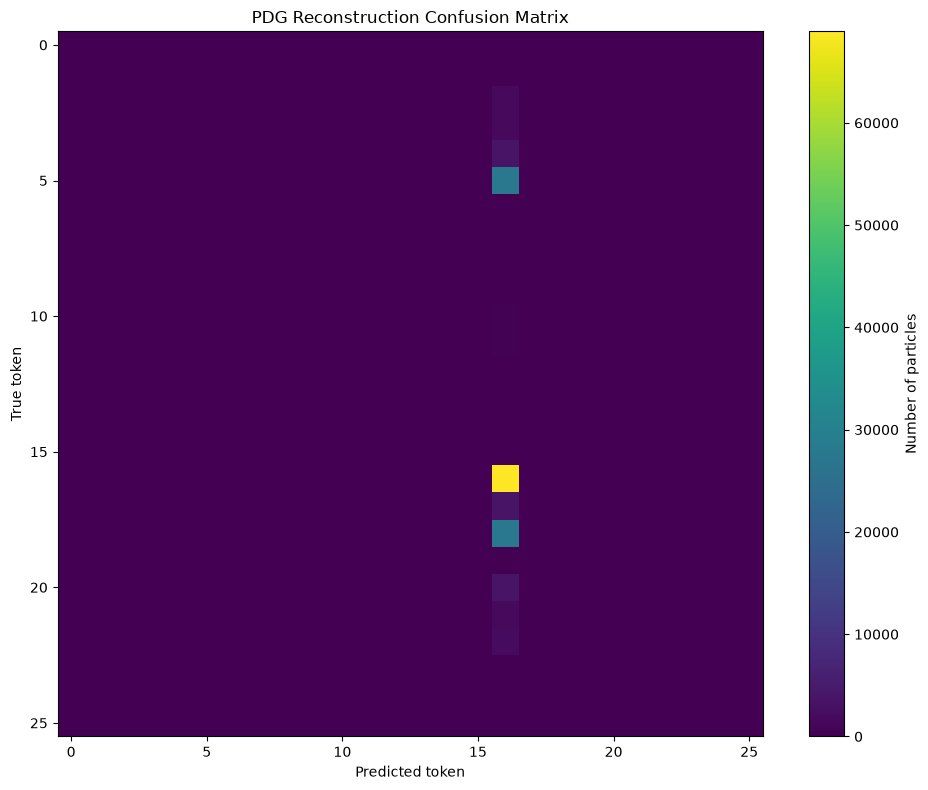

In [17]:
cm = confusion_matrix(
    test_targets,
    test_predictions
)

plt.figure(figsize=(10, 8))

plt.imshow(cm)

plt.xlabel("Predicted token")
plt.ylabel("True token")

plt.title("PDG Reconstruction Confusion Matrix")

plt.colorbar(label="Number of particles")

plt.tight_layout()
plt.show()

# Continuous-feature reconstruction

In [18]:
def evaluate_feature_reconstruction(
    model,
    loader,
    mask_ratio=0.40
):

    model.eval()

    predictions = []
    targets = []

    with torch.no_grad():

        for batch in loader:

            features = batch["features"].to(device)
            pdg = batch["pdg"].to(device)
            padding_mask = batch["padding_mask"].to(device)

            mask = create_mask(
                padding_mask,
                mask_ratio
            )

            predicted_features, _ = model(
                features,
                pdg,
                padding_mask,
                mask
            )

            predictions.append(
                predicted_features[mask].cpu()
            )

            targets.append(
                features[mask].cpu()
            )

    predictions = torch.cat(
        predictions
    ).numpy()

    targets = torch.cat(
        targets
    ).numpy()

    return predictions, targets

In [19]:
feature_predictions, feature_targets = evaluate_feature_reconstruction(
    model,
    test_loader
)

print("Prediction shape:", feature_predictions.shape)
print("Target shape:", feature_targets.shape)

Prediction shape: (144403, 7)
Target shape: (144403, 7)


# Calculate feature-by-feature errors

In [20]:
feature_names = [
    "log_pt",
    "eta",
    "sin_phi",
    "cos_phi",
    "log_energy",
    "log_mass",
    "charge"
]

print("=" * 70)

for i, name in enumerate(feature_names):

    error = feature_predictions[:, i] - feature_targets[:, i]

    mae = np.mean(np.abs(error))

    rmse = np.sqrt(
        np.mean(error**2)
    )

    correlation = np.corrcoef(
        feature_predictions[:, i],
        feature_targets[:, i]
    )[0, 1]

    print(
        f"{name:12s} | "
        f"MAE = {mae:.4f} | "
        f"RMSE = {rmse:.4f} | "
        f"Correlation = {correlation:.4f}"
    )

print("=" * 70)

log_pt       | MAE = 0.7651 | RMSE = 1.0032 | Correlation = 0.1342
eta          | MAE = 0.7410 | RMSE = 0.9974 | Correlation = 0.1480
sin_phi      | MAE = 0.8851 | RMSE = 0.9889 | Correlation = 0.1599
cos_phi      | MAE = 0.8817 | RMSE = 0.9868 | Correlation = 0.1618
log_energy   | MAE = 0.7836 | RMSE = 1.0083 | Correlation = 0.0906
log_mass     | MAE = 0.6666 | RMSE = 0.9949 | Correlation = 0.0808
charge       | MAE = 0.7254 | RMSE = 0.9893 | Correlation = 0.1402


### Interpretation of continuous feature reconstruction

The reconstruction errors indicate that the current model captures only limited
particle-level information for the continuous features. The correlations are relatively
weak, suggesting that the reconstruction task could benefit from further optimization.

However, this project focuses on demonstrating the self-supervised masked modeling
pipeline and evaluating the learned representations rather than achieving optimized
state-of-the-art reconstruction performance.

# Plot predicted vs true features

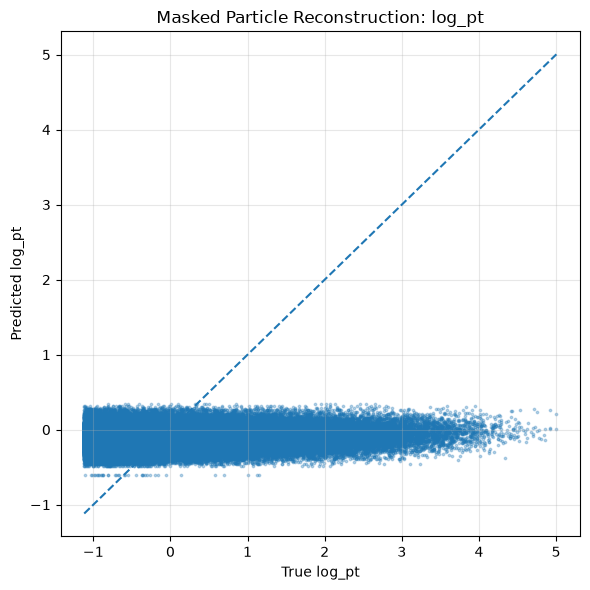

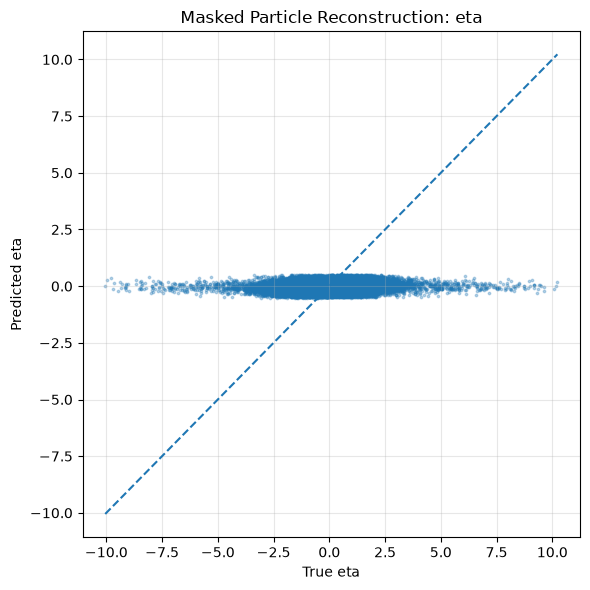

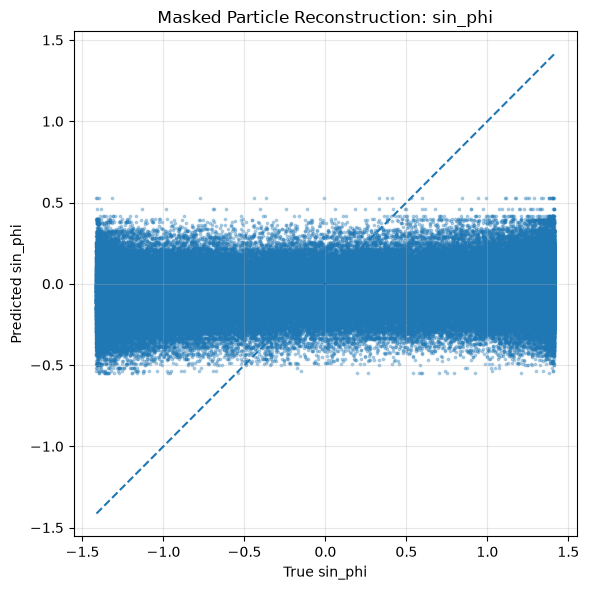

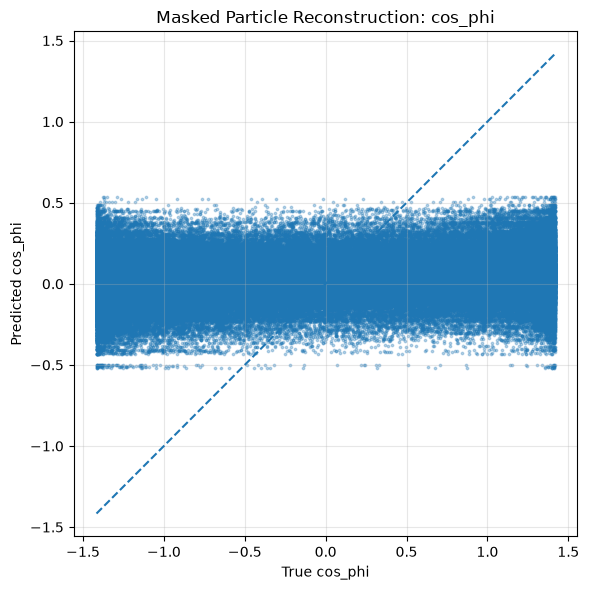

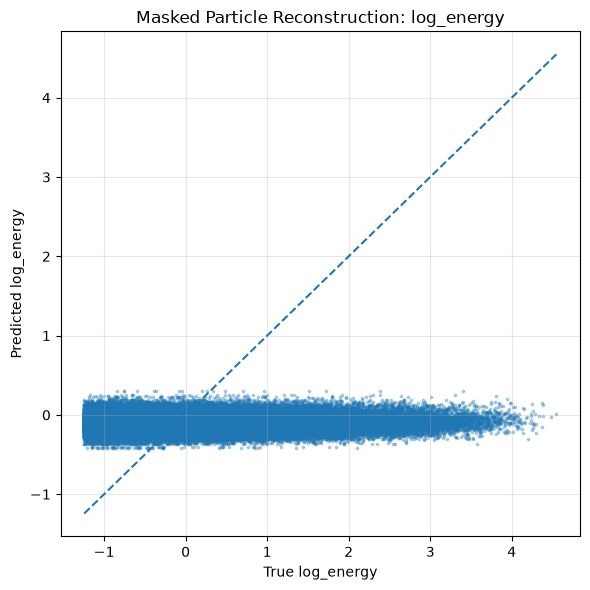

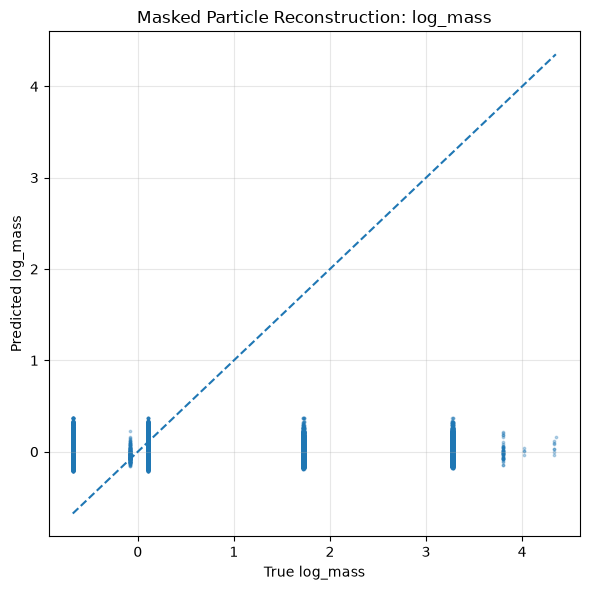

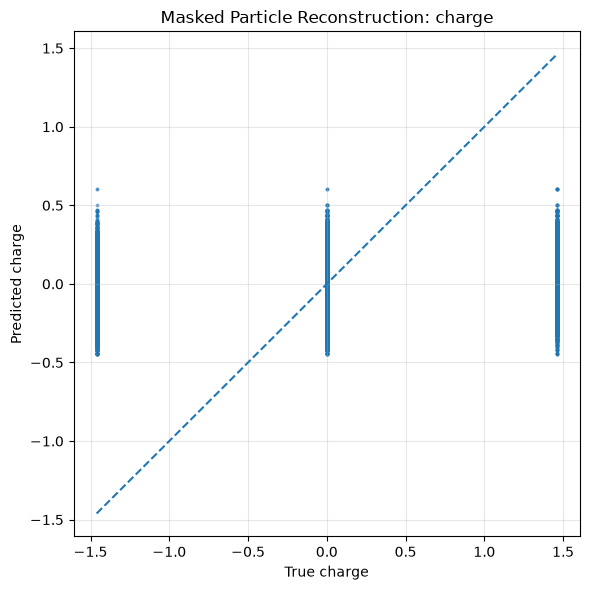

In [21]:
for i, name in enumerate(feature_names):

    plt.figure(figsize=(6, 6))

    plt.scatter(
        feature_targets[:, i],
        feature_predictions[:, i],
        s=3,
        alpha=0.3
    )

    minimum = min(
        feature_targets[:, i].min(),
        feature_predictions[:, i].min()
    )

    maximum = max(
        feature_targets[:, i].max(),
        feature_predictions[:, i].max()
    )

    plt.plot(
        [minimum, maximum],
        [minimum, maximum],
        linestyle="--"
    )

    plt.xlabel(f"True {name}")
    plt.ylabel(f"Predicted {name}")

    plt.title(
        f"Masked Particle Reconstruction: {name}"
    )

    plt.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

# Extract event embeddings

In [22]:
@torch.no_grad()
def extract_event_embeddings(
    model,
    loader
):

    model.eval()

    embeddings = []
    multiplicities = []

    for batch in loader:

        features = batch["features"].to(device)
        pdg = batch["pdg"].to(device)
        padding_mask = batch["padding_mask"].to(device)

        mask = torch.zeros_like(
            padding_mask
        )

        x = model.embedding(
            features,
            pdg,
            mask
        )

        x = model.transformer(
            x,
            src_key_padding_mask=padding_mask
        )

        valid = (
            ~padding_mask
        ).unsqueeze(-1)

        x_masked = x * valid

        event_embedding = (
            x_masked.sum(dim=1)
            /
            valid.sum(dim=1).clamp(min=1)
        )

        embeddings.append(
            event_embedding.cpu()
        )

        multiplicities.append(
            batch["lengths"]
        )

    embeddings = torch.cat(
        embeddings,
        dim=0
    )

    multiplicities = torch.cat(
        multiplicities,
        dim=0
    )

    return embeddings, multiplicities

In [23]:
test_embeddings, test_multiplicities = extract_event_embeddings(
    model,
    test_loader
)

print("Event embeddings:", test_embeddings.shape)
print("Multiplicities:", test_multiplicities.shape)

Event embeddings: torch.Size([4583, 128])
Multiplicities: torch.Size([4583])


# PCA of the learned event representation

In [24]:
from sklearn.decomposition import PCA

pca = PCA(
    n_components=2
)

embedding_2d = pca.fit_transform(
    test_embeddings.numpy()
)

print("Explained variance ratio:")
print(pca.explained_variance_ratio_)

print(
    "Total:",
    pca.explained_variance_ratio_.sum()
)

Explained variance ratio:
[0.20820832 0.18216671]
Total: 0.39037502


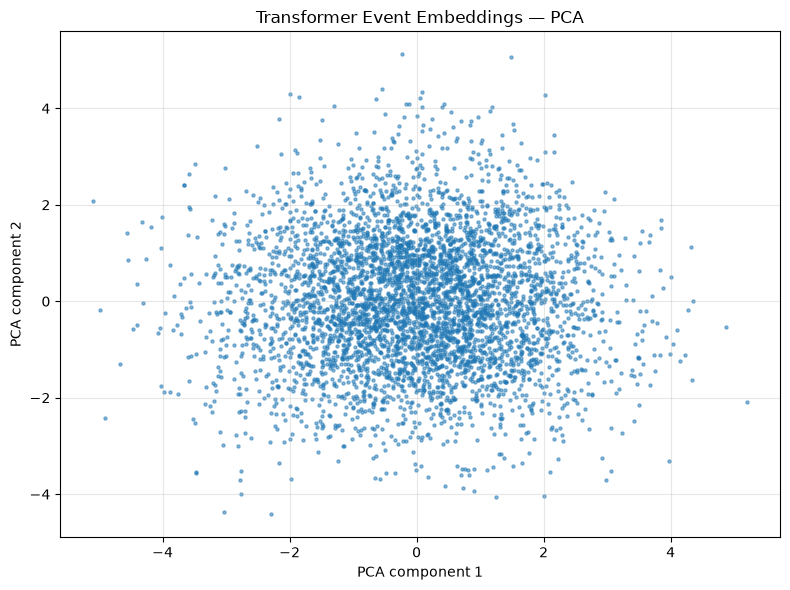

In [25]:
plt.figure(figsize=(8, 6))

plt.scatter(
    embedding_2d[:, 0],
    embedding_2d[:, 1],
    s=5,
    alpha=0.5
)

plt.xlabel("PCA component 1")
plt.ylabel("PCA component 2")

plt.title(
    "Transformer Event Embeddings — PCA"
)

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# color PCA by particle multiplicity

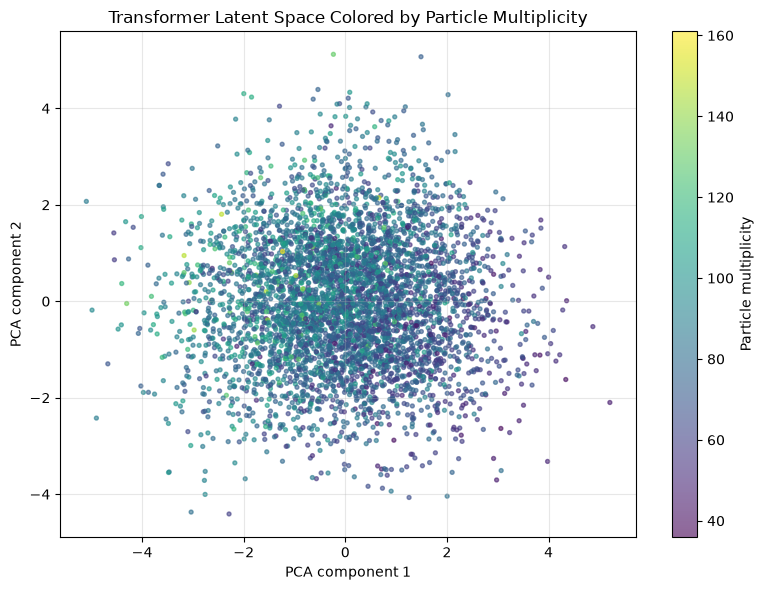

In [26]:
plt.figure(figsize=(8, 6))

scatter = plt.scatter(
    embedding_2d[:, 0],
    embedding_2d[:, 1],
    c=test_multiplicities.numpy(),
    s=8,
    alpha=0.6
)

plt.xlabel("PCA component 1")
plt.ylabel("PCA component 2")

plt.title(
    "Transformer Latent Space Colored by Particle Multiplicity"
)

plt.colorbar(
    scatter,
    label="Particle multiplicity"
)

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Correlation between embedding and multiplicity

In [27]:
from scipy.stats import pearsonr, spearmanr

pearson_r, pearson_p = pearsonr(
    embedding_2d[:, 0],
    test_multiplicities.numpy()
)

spearman_r, spearman_p = spearmanr(
    embedding_2d[:, 0],
    test_multiplicities.numpy()
)

print("Pearson correlation :", pearson_r)
print("Pearson p-value     :", pearson_p)

print("Spearman correlation:", spearman_r)
print("Spearman p-value    :", spearman_p)

Pearson correlation : -0.35702519314207726
Pearson p-value     : 7.567590119749731e-138
Spearman correlation: -0.34708749596464156
Spearman p-value    : 6.866644505042671e-130


# Conclusion

The masked particle transformer was evaluated using reconstruction metrics and
event-level latent representations.

The reconstruction analysis revealed limitations in the current model, particularly
for imbalanced PDG token prediction and continuous feature reconstruction. These
results provide useful diagnostic information about the learned model.

Despite these limitations, the extracted event embeddings show structured variation.
The PCA analysis demonstrates that the learned latent space contains information related
to particle multiplicity, with a moderate correlation between the first principal
component and event multiplicity.

Overall, this project demonstrates a complete workflow from collider data preparation
to self-supervised transformer training and representation evaluation. Future work
could investigate class-balanced objectives, improved masking strategies, and
downstream physics tasks.